In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayaanmustafa/vrs-bench")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ayaanmustafa/vrs-bench


In [2]:
pip install transformers datasets pillow torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [3]:
import json

path = "/kaggle/input/datasets/ayaanmustafa/vrs-bench/vrsbench_data/VRSBench_train.json"

with open(path, "r") as f:
    data = json.load(f)

print("Total samples:", len(data))
print("Sample:", data[0])

Total samples: 142390
Sample: {'id': 'Final_Data/v1.2', 'image': '00002_0000.png', 'conversations': [{'from': 'human', 'value': '<image>\n[caption] Could you describe the contents of this image for me?'}, {'from': 'gpt', 'value': 'The image, sourced from GoogleEarth, shows a rural area with an expressway-toll-station situated at the center. Alongside the toll station, multiple small vehicles are visible, with one positioned on the middle-left and another that is the right-most in the center relative to the toll station.'}]}


In [4]:
print("Sample:", data[1])

Sample: {'id': 'Final_Data/v1.2', 'image': '00002_0000.png', 'conversations': [{'from': 'human', 'value': '<image>\n[refer] could you tell me the location for <p>The toll station is positioned at the center of the image</p>?'}, {'from': 'gpt', 'value': '{<45><45><59><59>}'}]}


In [5]:
print("Sample:", data[20])

Sample: {'id': 'Final_Data/v1.2', 'image': '00005_0000.png', 'conversations': [{'from': 'human', 'value': '<image>\n[refer] the location of <p>The small vehicle is situated in the central part of the area</p> is '}, {'from': 'gpt', 'value': '{<37><48><39><51>}'}]}


In [6]:
# {
#   "image": "00002_0000.png",
#   "conversations": [
#     {"from": "human", "value": "<image>\n[caption] Could you describe the contents of this image for me?"},
#     {"from": "gpt", "value": "The image shows ..."}
#   ]
# }

In [7]:
# Convert to BLIP Format

# BLIP expects:

# {
#   "image": "...",
#   "text_input": "...",
#   "text_output": "..."
# }

In [8]:
import json
import os

# Paths

ann_dir = "/kaggle/input/datasets/ayaanmustafa/vrs-bench/vrsbench_data/Annotations_train/Annotations_train"

img_dir = "/kaggle/input/datasets/ayaanmustafa/vrs-bench/vrsbench_data/Images_train/Images_train"

output_path = "/kaggle/working/blip_train_vrs.json"
converted = []

for file in os.listdir(ann_dir):
    if file.endswith(".json"):
        with open(os.path.join(ann_dir, file)) as f:
            item = json.load(f)

        # Skip if no caption
        if "caption" not in item:
            continue

        image_name = item["image"]
        image_path = os.path.join(img_dir, image_name)

        converted.append({
            "image": image_path,
            "caption": item["caption"]
        })

# Save
with open(output_path, "w") as f:
    json.dump(converted, f, indent=2)

print("Total samples:", len(converted))

Total samples: 20264


In [9]:
import json

with open("/kaggle/working/blip_train_vrs.json") as f:
    data = json.load(f)

print(data[0])

{'image': '/kaggle/input/datasets/ayaanmustafa/vrs-bench/vrsbench_data/Images_train/Images_train/P1439_0001.png', 'caption': 'The image from GoogleEarth, with high resolution, shows vehicles parked in different sections. There are large and small vehicles parked up horizontally on top and bottop part of the image.'}


Exists: True


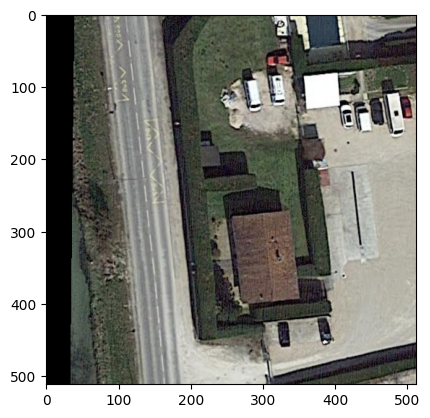

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = "/kaggle/input/datasets/ayaanmustafa/vrs-bench/vrsbench_data/Images_train/Images_train/P1439_0001.png"


print("Exists:", os.path.exists(image_path))

img = Image.open(image_path)

plt.imshow(img)


In [11]:
print(data[0]["caption"])

The image from GoogleEarth, with high resolution, shows vehicles parked in different sections. There are large and small vehicles parked up horizontally on top and bottop part of the image.


In [12]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model.to(device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [13]:
from torch.utils.data import Dataset
from PIL import Image
import json

class VRSCaptionDataset(Dataset):
    def __init__(self, json_path):
        with open(json_path, "r") as f:
            self.data = json.load(f)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        image = Image.open(item["image"]).convert("RGB")
        caption = item["caption"]

        inputs = processor(
            images=image,
            text=caption,
            return_tensors="pt",
            padding="max_length",
            truncation=True
        )

        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = inputs["input_ids"]

        return inputs

In [14]:
from torch.utils.data import DataLoader

train_dataset = VRSCaptionDataset("/kaggle/working/blip_train_vrs.json")

train_loader = DataLoader(
    train_dataset,
    batch_size=4,   
    shuffle=True
)

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

model.train()

for epoch in range(2):   
    print(f"\nEpoch {epoch+1}")

    total_loss = 0

    for i, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        if i % 100 == 0:
            print(f"Step {i}, Loss: {loss.item()}")

    print("Epoch Loss:", total_loss / len(train_loader))


Epoch 1
Step 0, Loss: 12.716852188110352
Step 100, Loss: 0.421658456325531
Step 200, Loss: 0.30934953689575195
Step 300, Loss: 0.20720043778419495
Step 400, Loss: 0.20765702426433563
Step 500, Loss: 0.3344962000846863
Step 600, Loss: 0.33362430334091187
Step 700, Loss: 0.28255176544189453
Step 800, Loss: 0.2617434859275818
Step 900, Loss: 0.2419373095035553
Step 1000, Loss: 0.26849550008773804
Step 1100, Loss: 0.23213514685630798
Step 1200, Loss: 0.32755059003829956
Step 1300, Loss: 0.23697400093078613
Step 1400, Loss: 0.24550671875476837
Step 1500, Loss: 0.17419546842575073
Step 1600, Loss: 0.1901078224182129
Step 1700, Loss: 0.29782235622406006
Step 1800, Loss: 0.19570192694664001
Step 1900, Loss: 0.18079112470149994
Step 2000, Loss: 0.2379317283630371
Step 2100, Loss: 0.16000032424926758
Step 2200, Loss: 0.18960632383823395
Step 2300, Loss: 0.22138839960098267
Step 2400, Loss: 0.3587231934070587
Step 2500, Loss: 0.25687897205352783
Step 2600, Loss: 0.20215319097042084
Step 2700, Lo

In [16]:
model.save_pretrained("/kaggle/working/blip_vrs_finetuned")
processor.save_pretrained("/kaggle/working/blip_vrs_finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/kaggle/working/blip_vrs_finetuned/processor_config.json']

In [17]:
import shutil

shutil.make_archive(
    '/kaggle/working/blip_vrs_finetuned',
    'zip',
    '/kaggle/working/blip_vrs_finetuned'
)

'/kaggle/working/blip_vrs_finetuned.zip'

In [18]:
from IPython.display import FileLink

FileLink('/kaggle/working/blip_vrs_finetuned.zip')

/kaggle/working/blip_vrs_finetuned.zip

In [19]:
import os

os.listdir('/kaggle/working/')

['blip_vrs_finetuned.zip',
 '.virtual_documents',
 'blip_vrs_finetuned',
 'blip_train_vrs.json']

In [20]:
import os
size = os.path.getsize('/kaggle/working/blip_vrs_finetuned.zip') / (1024*1024)
print(f"{size:.2f} MB")

875.16 MB
